In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

### Load data

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")
results = np.load("Results/rollout_global/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
feature_names_short = ['1,5-Anhydrosorbitol', '2-Aminobutyric \n acid', '2-Hydroxybutyric \n acid', 
                       '2-Oxoglutaric \n acid', '3-Hydroxyisobutyric \n acid', 'Acetic \n acid', 
                       'Acetoacetic \n acid', 'Acetone', 'Alanine', 'Albumin', 
                       'Apolipoprotein B', 'Arginine', 'Asparagine', 'Aspartate', 
                       'BCAA to AAA \n ratio', 'Betaine', 'Bilirubin', 'C reactive \n protein', 
                       'Calcium', 'Choline', 'Citric \n acid', 'Creatine', 'Creatinine', 
                       'Cystine', 'D-Galactose', 'Dimethylamine', 'Dimethylsulfone', 
                       'Erythrocyte \n sedimentation \n rate', 'Erythrocytes', 
                       'Estimated \n Glomerular \n Filtration \n Rate', 'Ethanol', 'Formic acid', 
                       'Glucose', 'Glutamic \n acid', 'Glutamine', 
                       'Glutamine to \n glutamate ratio', 'Glyc A', 'GlycB to \n GlycA ratio', 
                       'Glycerol', 'Glycine', 'HDL cholesterol', 'Histidine', 'Iron', 
                       'LDL cholesterol', 'Lactate to \n pyruvate ratio', 'Lactic acid', 
                       'Leucine', 'Leukocytes', 'Lipoprotein(a)', 'Lysine', 
                       'Methanol', 'Methionine', 'Myo-inositol', 'N,N-Dimethylglycine', 
                       'Non-albumin \n protein', 'Ornithine', 'Phenylalanine', 'Platelets', 
                       'Proline', 'Pyruvic \n acid', 'SPC', 'Sarcosine', 'Serine', 
                       'Succinic \n acid', 'Threonine', 'Transferrin', 'Triglycerides', 
                       'Trimethylamine-N-oxide', 'Tyrosine', 'Urate', 'Urea', 
                       'Urea to creatinine \n ratio']

In [4]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

### Interaction graph (top-k)

In [5]:
def select_top_nodes(R, feature_names, top_m=15):
    importance = R.sum(axis=0)  # received attention
    
    top_idx = np.argsort(importance)[-top_m:]
    top_idx = top_idx[np.argsort(importance[top_idx])[::-1]]
        
    R_sub = R[np.ix_(top_idx, top_idx)]
    imp_sub = importance[top_idx]
    feature_names_sub = [feature_names[i] for i in top_idx]

    return R_sub, imp_sub, feature_names_sub, top_idx

In [6]:
R_sub, imp_sub, feature_names_sub, top_idx = select_top_nodes(results['rollout'], 
                                                     feature_abbrev, 
                                                     top_m=15)

### Attention matrices

In [7]:
with open("Results/rollout_local/attn_matrices.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

In [8]:
attn_list = [np.mean(attn_matrices[key]['attn_matrix'], axis=0) for key in attn_matrices.keys()]

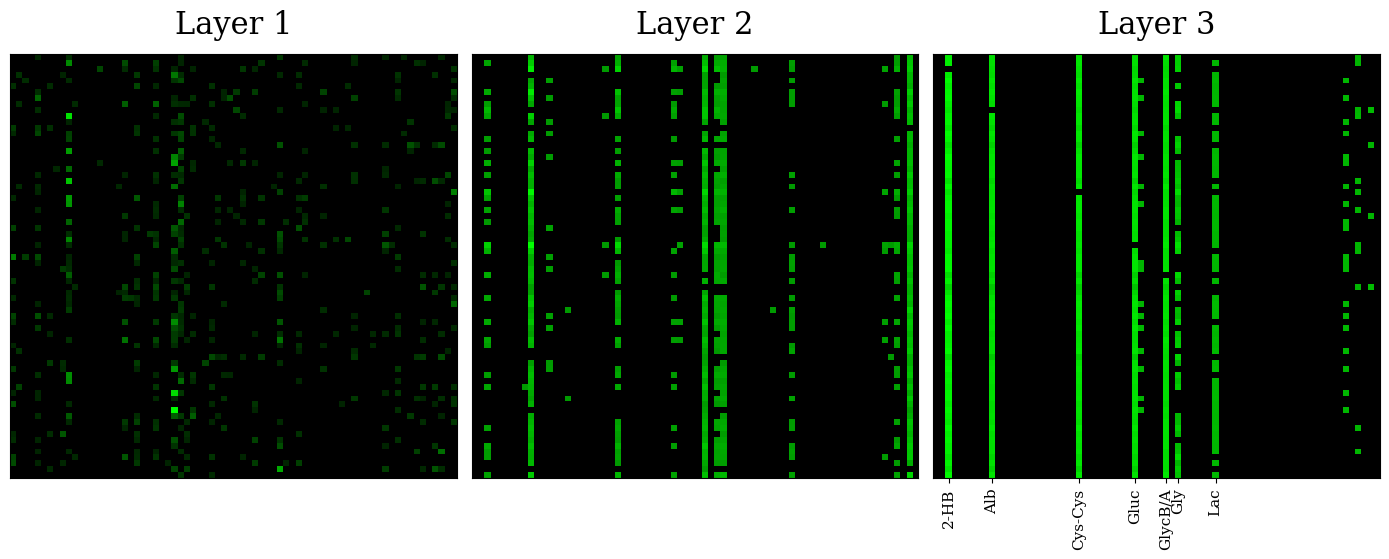

In [9]:
lst_plot = ['2-HB', 'Alb', 'Cys-Cys', 'Gluc', 'GlycB/A', 'Gly', 'Lac']
indices = [i for i, x in enumerate(feature_abbrev) if x in lst_plot]

plt.rcParams.update({
    # "font.size": 8,
    "font.family": "serif",
    # "axes.linewidth": 0.6,
    # "xtick.major.width": 0.6,
    # "ytick.major.width": 0.6,
    # "xtick.major.size": 3,
    # "ytick.major.size": 0,
    # "pdf.fonttype": 42,
    # "ps.fonttype": 42,
    # "svg.fonttype": "none",
})

n_plot = len(attn_list)

fig, axes = plt.subplots(1, n_plot, figsize=(14,5.7))

cmap_attn = LinearSegmentedColormap.from_list("black_green",
                                              ["black", "#00FF00"])    

for (i, attn_matrix) in enumerate(attn_list):
    matrix = attn_matrix.copy()
    np.fill_diagonal(matrix, 0)
    matrix = sparsify_global_percentile(matrix, q=90, keep_diagonal=False)

    axes[i].imshow(matrix, aspect='auto', cmap=cmap_attn)
    axes[i].set_title(rf"Layer {i+1}", fontsize = 22, pad=15)     
             
    # plt.title(title, fontsize=40, pad=10)   

    if i == 2:
        axes[i].set_xticks(ticks=indices,
                    labels=lst_plot,
                    rotation=90,
                    fontsize=11)
    else: 
        axes[i].set_xticks([])
        
    axes[i].set_yticks([])
    
plt.tight_layout()
plt.savefig("Results/attention_matrices.pdf", bbox_inches="tight")
plt.show()

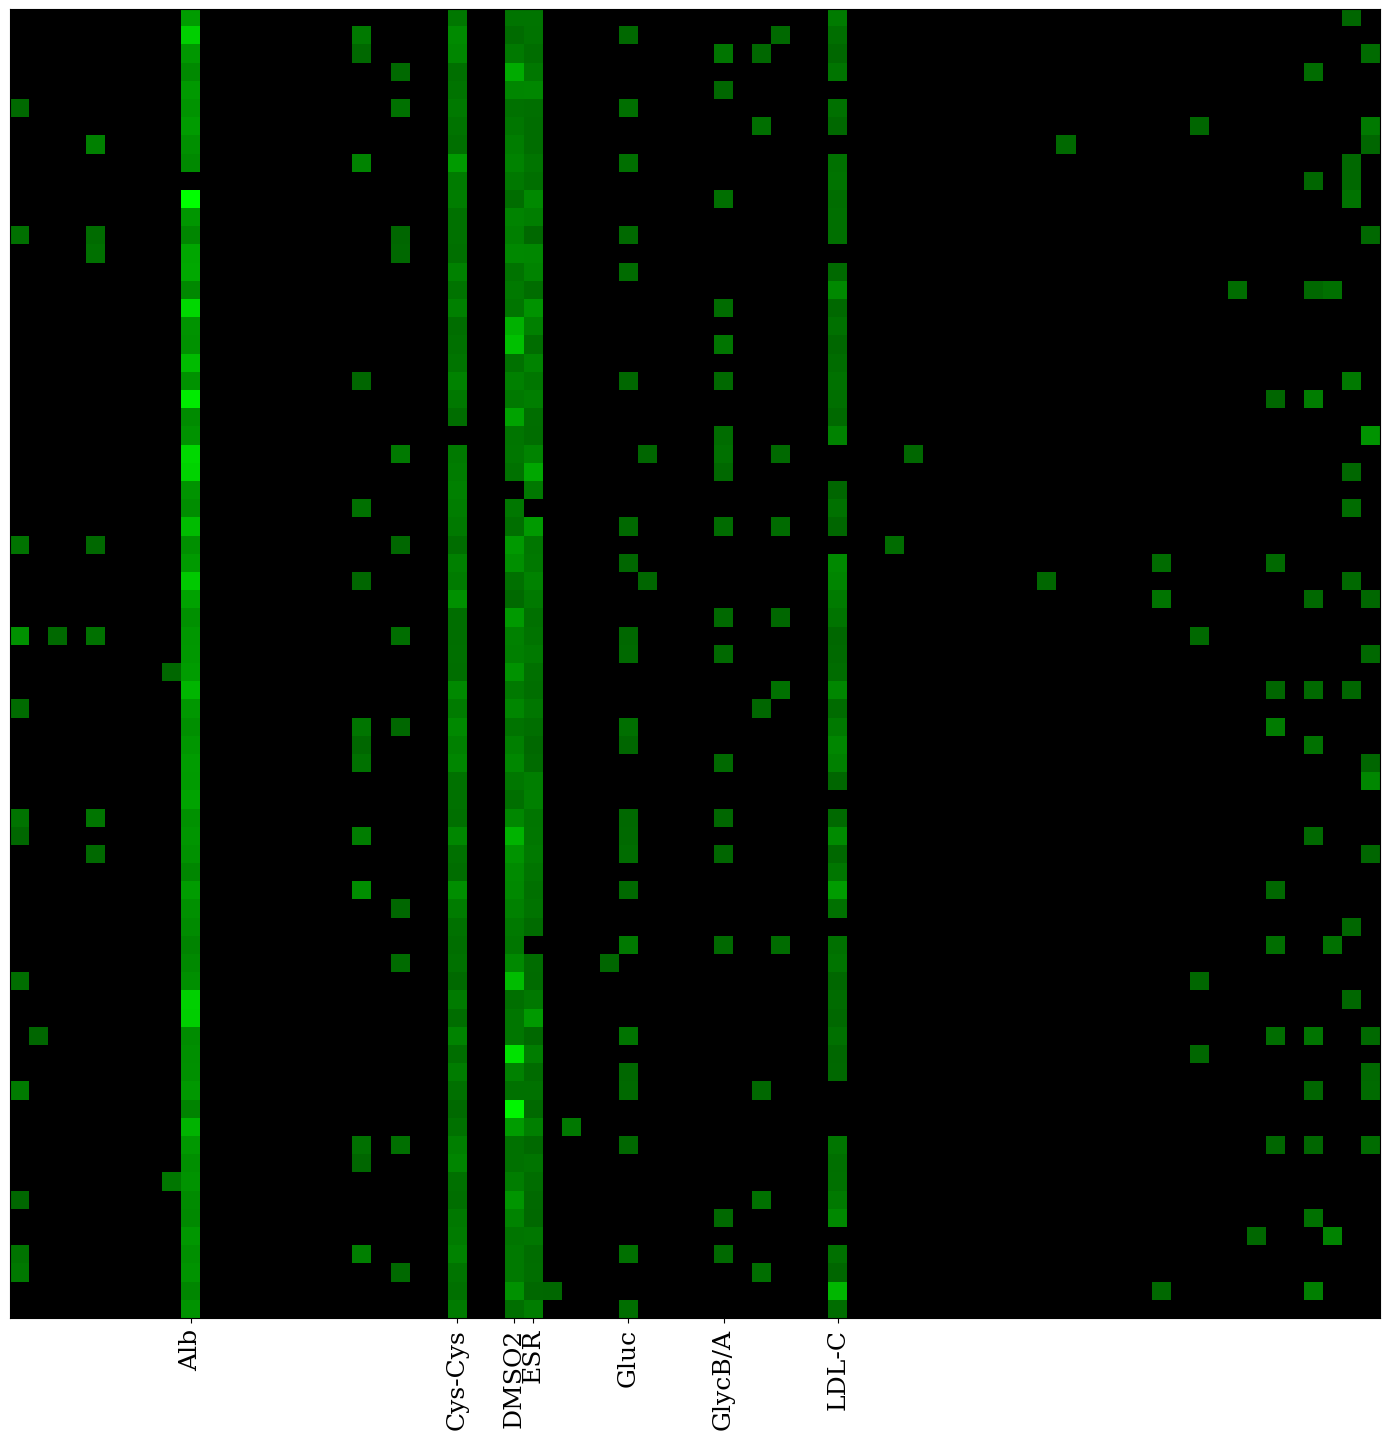

In [15]:
lst_plot_R = ['Alb', 'Cys-Cys', 'DMSO2', 'ESR', 'Gluc', 'GlycB/A', 'LDL-C']
indices_R = [i for i, x in enumerate(feature_abbrev) if x in lst_plot_R]

R = results['rollout']
np.fill_diagonal(R, 0)
R = sparsify_global_percentile(R, q=90, keep_diagonal=False)

# plt.figure(figsize=(10, 11))
plt.figure(figsize=(14, 14.5))
im = plt.imshow(R, aspect='auto', cmap=cmap_attn)

# plt.title("Attention rollout", fontsize=38, pad=10)   

# plt.xticks(ticks=np.arange(len(feature_abbrev)),
#            labels=feature_abbrev,
#            rotation=90,
#            fontsize=11)

plt.xticks(ticks=indices_R,
           labels=lst_plot_R,
           rotation=90,
           fontsize=18)

plt.yticks([])

plt.tight_layout()
plt.savefig("Results/attention_rollout.pdf", bbox_inches="tight")
plt.show()